In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
%matplotlib inline

In [3]:
df = pd.read_csv("../data/SFMTA_-_Parking_Citations_&_Fines_20260209 (1).csv")
df.head()

/var/folders/ys/_jtkggyd0hn93xqgmvmv3yy00000gp/T/ipykernel_67552/3034697842.py:1: DtypeWarning: Columns (9,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/SFMTA_-_Parking_Citations_&_Fines_20260209 (1).csv")


,Citation Number,Citation Issued DateTime,Violation,Violation Description,Citation Location,Vehicle Plate State,Vehicle Plate,Fine Amount,Date Added,geom,supervisor_district,analysis_neighborhood,Latitude,Longitude
0,"""11560780T",2026 Feb 04 07:56:00 PM,TRC7.2.101A,FAIL DISPL,NaN,NaN,NaN,$0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN
1,"""11560776T",2026 Feb 04 07:52:00 PM,TRC7.2.101A,FAIL DISPL,NaN,NaN,NaN,$0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN
2,"""11561605T",2026 Feb 04 07:41:00 PM,TRC7.2.101A,FAIL DISPL,METRO FOREST HILL STATION-DOWNTOWN,NaN,NaN,$134,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN
3,"""11553500T",2026 Feb 04 07:41:00 PM,TRC7.2.101A,FAIL DISPL,NaN,NaN,NaN,$0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN
4,"""998115893",2026 Feb 04 07:40:00 PM,TRC7.2.40,PRK PROHIB,101 05TH ST,AL,3A0C313,$108,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN


**Get a new column: Year**

In [4]:
def getYear(year):
    return year.split()[0]

df['Year'] = df['Citation Issued DateTime'].apply(getYear)

**Change the "Fine Amount" column to be in integer format**

In [5]:
def getMoney(money):
    return int(money.split('$')[1].replace(",",""))

df['Fine Amount'] = df['Fine Amount'].apply(getMoney)

**Get the fine amount by year**

In [7]:
years = df.groupby('Year')['Fine Amount'].sum()
plot_years = pd.DataFrame(years).reset_index()
plot_years

,Year,Fine Amount
0,2016,110391713
1,2017,119218579
2,2018,120999385
3,2019,118408552
4,2020,70746406
5,2021,104761780
6,2022,107376875
7,2023,107532429
8,2024,128374224
9,2025,174476465


**Plot the fine amount by year**

<Figure size 2000x1000 with 0 Axes>

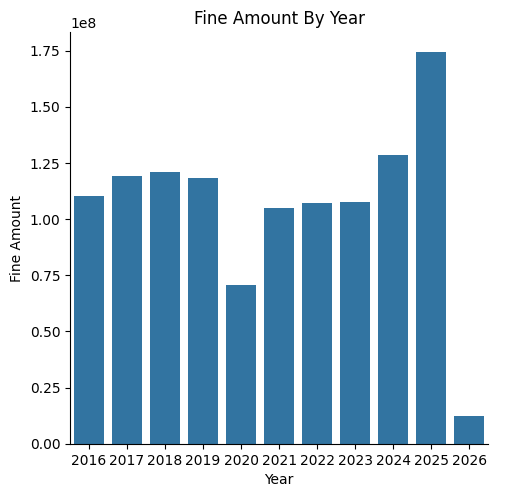

In [8]:
plt.figure(figsize = (20,10))
sns.catplot(
    data = plot_years,
    x = 'Year',
    y = 'Fine Amount',
    kind = 'bar'
)
plt.title("Fine Amount By Year")
plt.show()

In [9]:
total_fine_amount = df['Fine Amount'].sum()
total_fine_amount

1174558848

In [11]:
df_25 = df[df['Year'] == '2025']
df_25

,Citation Number,Citation Issued DateTime,Violation,Violation Description,Citation Location,Vehicle Plate State,Vehicle Plate,Fine Amount,Date Added,geom,supervisor_district,analysis_neighborhood,Latitude,Longitude,Year
110387,"""996787993",2025 Dec 31 11:58:00 PM,TRC7.2.40,PRK PROHIB,200 MISSION ST,CA,9UEH847,108,2026 Jan 25 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2025
110388,"""PD39541950",2025 Dec 31 11:55:00 PM,PK6.01H,MAR GRN PK,ONE MARINA GREEN DR,CA,IBDVS1,23,2026 Feb 02 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2025
110389,"""PD39541946",2025 Dec 31 11:49:00 PM,PK7.03U,NO PERMIT,3950 SCOTT ST,CA,9VYJ188,23,2026 Jan 31 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2025
110390,"""PD40884130",2025 Dec 31 11:45:00 PM,V22500I,BUS ZONE,2100 BLK UNION ST,CA,63578L3,443,2026 Jan 21 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2025
110391,"""PD38928772",2025 Dec 31 11:44:00 PM,TRC7.2.42,RESTRICTED,THE PALMS,CA,9WGD784,108,2026 Feb 07 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1720056,PD36827851,2025 Jan 01 12:00:00 AM,TRC7.2.25,RED ZONE,1275 GREENWICH,CA,40244Z3,108,2025 Mar 15 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2025
1720057,PD39543556,2025 Jan 01 12:00:00 AM,PK6.01G,NOPRK 10P6,1 LAKE MERCED BLVD,CA,HN188DP,23,2025 Jan 15 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2025
1720058,PD38008434,2025 Jan 01 12:00:00 AM,V22500H,DBL PARK,2732 MISSION STREET,CA,9MGH029,108,2025 Jun 03 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2025
1720059,1004672745,2025 Jan 01 12:00:00 AM,TRC7.2.25,RED ZONE,4396 JADAH,CA,7XTJ019,108,2025 Feb 18 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2025


**Work on changing the Citation location to the street**

In [12]:
locations = df_25['Citation Location'].dropna()
locations.head()

110387         200 MISSION ST
110388    ONE MARINA GREEN DR
110389          3950 SCOTT ST
110390      2100 BLK UNION ST
110391              THE PALMS
Name: Citation Location, dtype: object

In [13]:
streets = locations.str.replace(r"\b\d+\b", "", regex= True)
streets.head(5)

110387             MISSION ST
110388    ONE MARINA GREEN DR
110389               SCOTT ST
110390           BLK UNION ST
110391              THE PALMS
Name: Citation Location, dtype: object

In [16]:
df_25

,Citation Number,Citation Issued DateTime,Violation,Violation Description,Citation Location,Vehicle Plate State,Vehicle Plate,Fine Amount,Date Added,geom,supervisor_district,analysis_neighborhood,Latitude,Longitude,Year,streets
110387,"""996787993",2025 Dec 31 11:58:00 PM,TRC7.2.40,PRK PROHIB,200 MISSION ST,CA,9UEH847,108,2026 Jan 25 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2025,MISSION ST
110388,"""PD39541950",2025 Dec 31 11:55:00 PM,PK6.01H,MAR GRN PK,ONE MARINA GREEN DR,CA,IBDVS1,23,2026 Feb 02 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2025,ONE MARINA GREEN DR
110389,"""PD39541946",2025 Dec 31 11:49:00 PM,PK7.03U,NO PERMIT,3950 SCOTT ST,CA,9VYJ188,23,2026 Jan 31 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2025,SCOTT ST
110390,"""PD40884130",2025 Dec 31 11:45:00 PM,V22500I,BUS ZONE,2100 BLK UNION ST,CA,63578L3,443,2026 Jan 21 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2025,BLK UNION ST
110391,"""PD38928772",2025 Dec 31 11:44:00 PM,TRC7.2.42,RESTRICTED,THE PALMS,CA,9WGD784,108,2026 Feb 07 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2025,THE PALMS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1720056,PD36827851,2025 Jan 01 12:00:00 AM,TRC7.2.25,RED ZONE,1275 GREENWICH,CA,40244Z3,108,2025 Mar 15 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2025,GREENWICH
1720057,PD39543556,2025 Jan 01 12:00:00 AM,PK6.01G,NOPRK 10P6,1 LAKE MERCED BLVD,CA,HN188DP,23,2025 Jan 15 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2025,LAKE MERCED BLVD
1720058,PD38008434,2025 Jan 01 12:00:00 AM,V22500H,DBL PARK,2732 MISSION STREET,CA,9MGH029,108,2025 Jun 03 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2025,MISSION STREET
1720059,1004672745,2025 Jan 01 12:00:00 AM,TRC7.2.25,RED ZONE,4396 JADAH,CA,7XTJ019,108,2025 Feb 18 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2025,JADAH


In [15]:
df_25['streets'] = streets

/var/folders/ys/_jtkggyd0hn93xqgmvmv3yy00000gp/T/ipykernel_67552/1172452885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_25['streets'] = streets


In [17]:
df_25['streets'].value_counts()

streets
 MISSION ST                   46005
 CALIFORNIA ST                18193
 POST ST                      15210
 SUTTER ST                    14559
 FOLSOM ST                    13716
                              ...  
 BLK DE ANZA ST                   1
LINCOLN WAY & 33RD AVE            1
 BLK ANZA ST                      1
 HARRIET  ST                      1
20TH STREET/ALABAMA STREET        1
Name: count, Length: 7568, dtype: int64

**Plot the most popular streets**

In [18]:
street_plot = pd.DataFrame(df_25['streets'].value_counts()).reset_index()

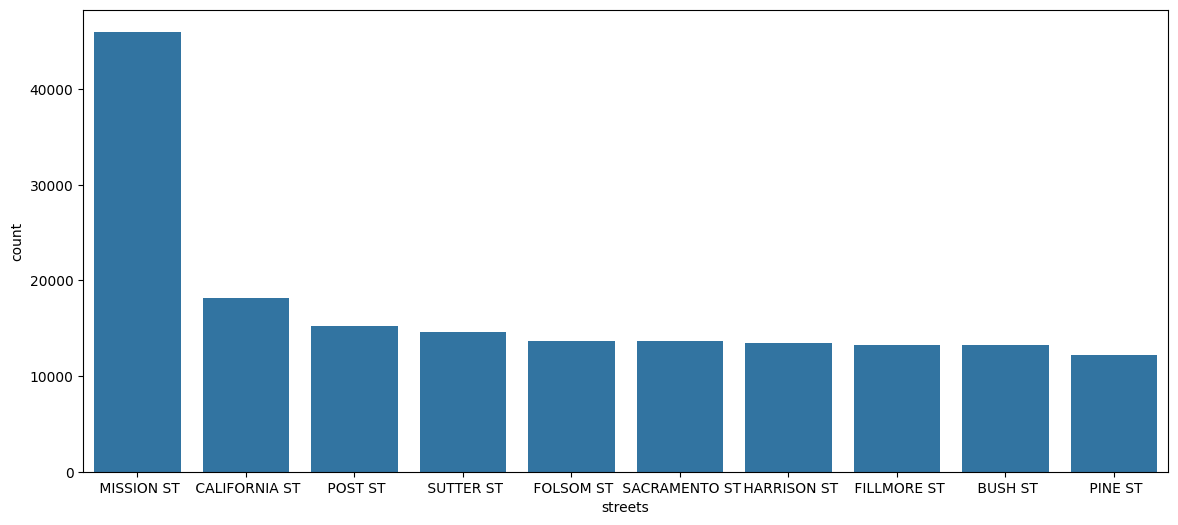

In [19]:
plt.figure(figsize=(14,6))
sns.barplot(
    data = street_plot.head(10),
    x = 'streets',
    y = 'count'
)
plt.show()

**Get hour for each day**

In [20]:
def get_time_of_day(timestamp_str):
    dt = datetime.strptime(timestamp_str, "%Y %b %d %I:%M:%S %p")
    hour = dt.hour  # 0–23 format

    return hour
df_25['Hour'] = df_25['Citation Issued DateTime'].apply(get_time_of_day)

/var/folders/ys/_jtkggyd0hn93xqgmvmv3yy00000gp/T/ipykernel_67552/1356621794.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_25['Hour'] = df_25['Citation Issued DateTime'].apply(get_time_of_day)


In [21]:
time_plot = pd.DataFrame(df_25['Hour'].value_counts()).reset_index()
time_plot

,Hour,count
0,12,241635
1,9,178524
2,8,129737
3,13,128535
4,10,122016
5,11,115920
6,7,91230
7,6,85502
8,15,83525
9,16,81781


<Axes: xlabel='Hour', ylabel='count'>

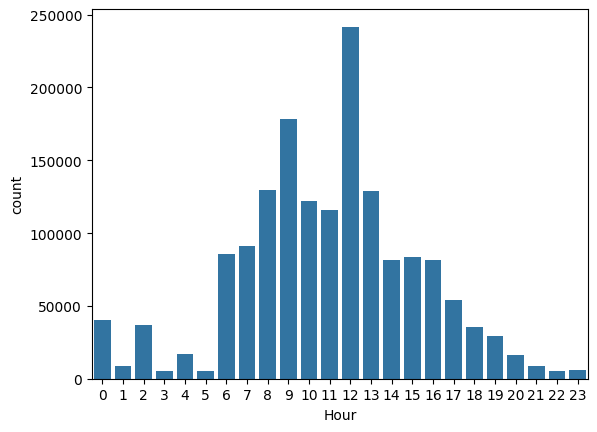

In [22]:
sns.barplot(
    data = time_plot,
    x = 'Hour',
    y = 'count'
)

**Plot day of week**

In [23]:
def get_day_of_week(timestamp_str):
    dt = datetime.strptime(timestamp_str, "%Y %b %d %I:%M:%S %p")
    return dt.strftime("%A")

df_25['Day Of Week'] = df_25['Citation Issued DateTime'].apply(get_day_of_week)

/var/folders/ys/_jtkggyd0hn93xqgmvmv3yy00000gp/T/ipykernel_67552/450016799.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_25['Day Of Week'] = df_25['Citation Issued DateTime'].apply(get_day_of_week)


In [24]:
day_plot = pd.DataFrame(df_25['Day Of Week'].value_counts()).reset_index()

<Axes: xlabel='Day Of Week', ylabel='count'>

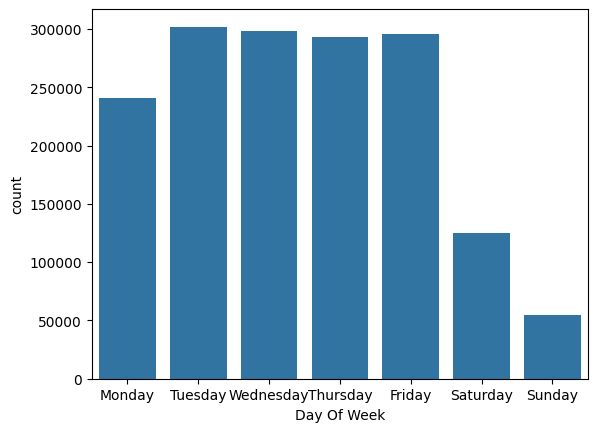

In [26]:
sns.barplot(
    data = day_plot,
    x = 'Day Of Week',
    y = 'count',
    order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

In [32]:
heat_plot = pd.crosstab(df_25['Hour'], df_25['Day Of Week'])

In [28]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df_25['Day Of Week'] = pd.Categorical(df_25['Day Of Week'], categories=day_order, ordered=True)

/var/folders/ys/_jtkggyd0hn93xqgmvmv3yy00000gp/T/ipykernel_67552/4025383608.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_25['Day Of Week'] = pd.Categorical(df_25['Day Of Week'], categories=day_order, ordered=True)


<Axes: xlabel='Day Of Week', ylabel='Hour'>

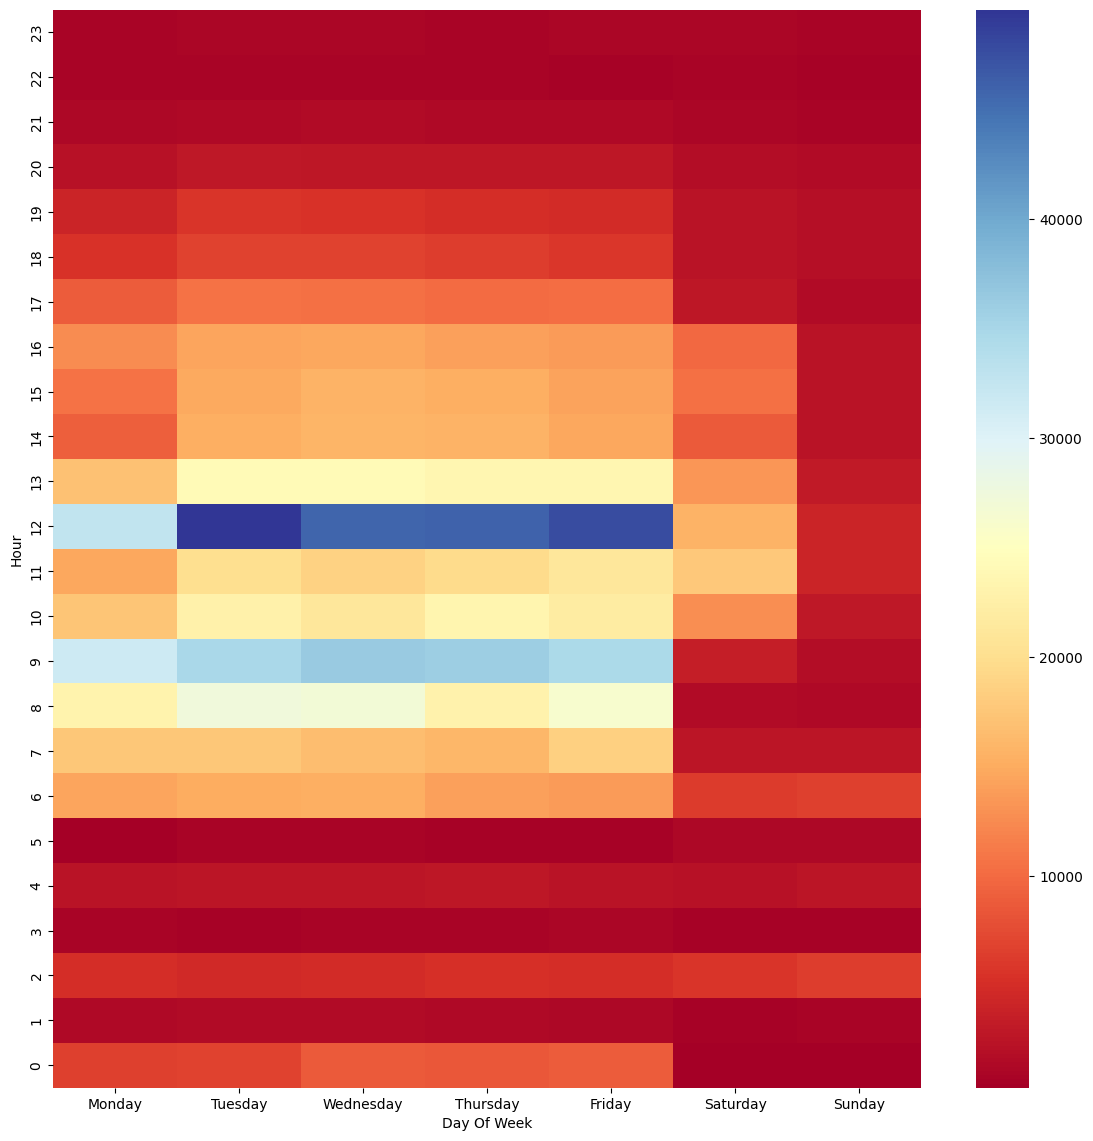

In [33]:
fig, ax = plt.subplots(figsize=(14, 14))
sns.heatmap(
    data = heat_plot.sort_index(ascending=False),
    annot= False,
    fmt = 'd',
    cmap = 'RdYlBu',
)

In [37]:
fine_amount_plot_day = pd.DataFrame(df_25.groupby('Day Of Week')['Fine Amount'].sum()).reset_index()
fine_amount_plot_day

/var/folders/ys/_jtkggyd0hn93xqgmvmv3yy00000gp/T/ipykernel_67552/3937008178.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fine_amount_plot_day = pd.DataFrame(df_25.groupby('Day Of Week')['Fine Amount'].sum()).reset_index()


,Day Of Week,Fine Amount
0,Monday,25890008
1,Tuesday,32509903
2,Wednesday,32266297
3,Thursday,31623882
4,Friday,32103308
5,Saturday,13737297
6,Sunday,6345770


<Axes: xlabel='Day Of Week', ylabel='Fine Amount'>

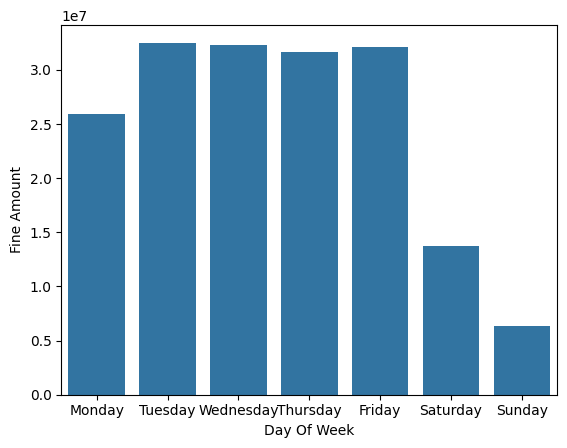

In [38]:
sns.barplot(
    data = fine_amount_plot_day,
    x = 'Day Of Week',
    y = 'Fine Amount'
)

In [39]:
fine_amount_plot_hour = pd.DataFrame(df_25.groupby('Hour')['Fine Amount'].sum()).reset_index()

<Axes: xlabel='Hour', ylabel='Fine Amount'>

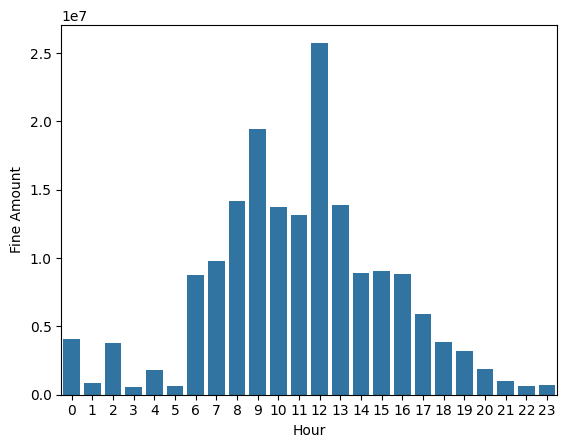

In [40]:
sns.barplot(
    data = fine_amount_plot_hour,
    x = 'Hour',
    y = 'Fine Amount'
)

<Axes: xlabel='streets', ylabel='Hour'>

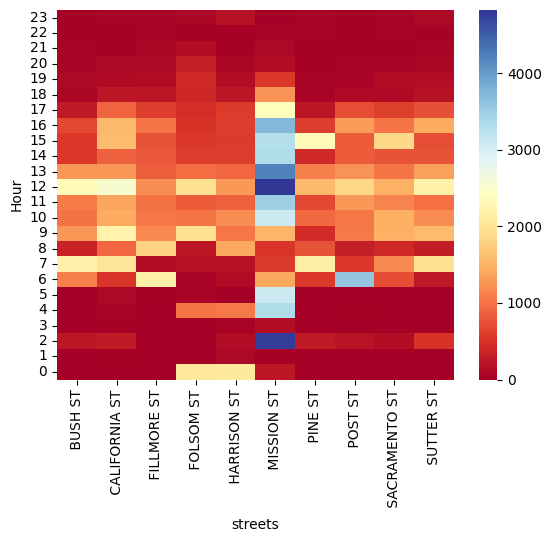

In [41]:
top_streets = df_25['streets'].value_counts().head(10).index
subset = df_25[df_25['streets'].isin(top_streets)]

heat = pd.crosstab(subset['Hour'],subset['streets'])

sns.heatmap(
              heat.sort_index(ascending=False)
            , cmap='RdYlBu',
              fmt = 'd',
            )

In [43]:
df_25.isna().sum()

Citation Number                   0
Citation Issued DateTime          0
Violation                        27
Violation Description            27
Citation Location             10875
Vehicle Plate State           61754
Vehicle Plate                 66392
Fine Amount                       0
Date Added                        0
geom                        1609672
supervisor_district         1609672
analysis_neighborhood       1609672
Latitude                    1609672
Longitude                   1609672
Year                              0
streets                       10875
Hour                              0
Day Of Week                       0
dtype: int64

In [44]:
df_25.columns

Index(['Citation Number', 'Citation Issued DateTime', 'Violation',
       'Violation Description', 'Citation Location', 'Vehicle Plate State',
       'Vehicle Plate', 'Fine Amount', 'Date Added', 'geom',
       'supervisor_district', 'analysis_neighborhood', 'Latitude', 'Longitude',
       'Year', 'streets', 'Hour', 'Day Of Week'],
      dtype='object')

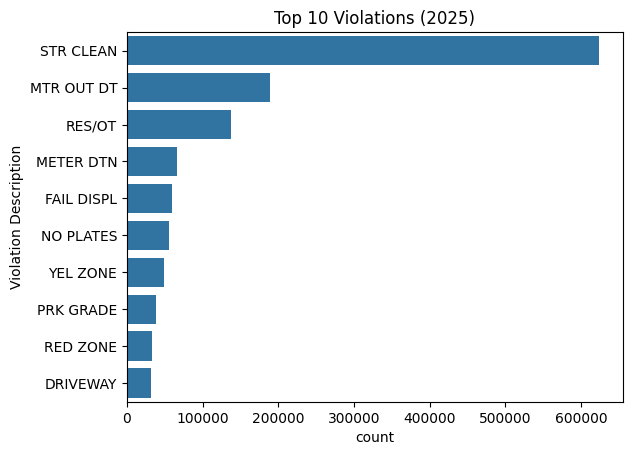

In [45]:
top_violations = df_25['Violation Description'].value_counts().head(10).index

sns.countplot(
    data=df_25,
    y='Violation Description',
    order=top_violations
)

plt.title('Top 10 Violations (2025)')
plt.show()

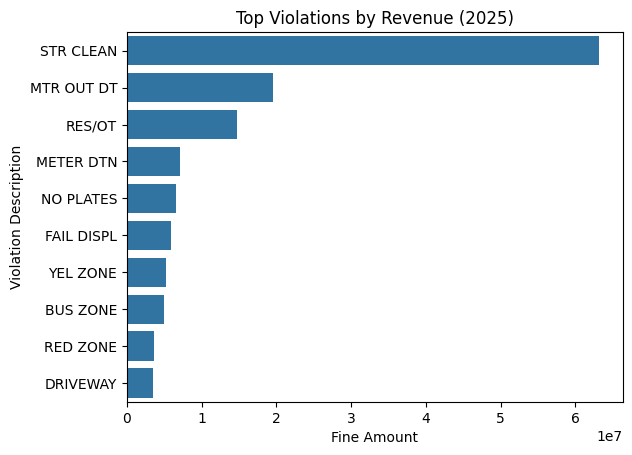

In [46]:
revenue = (
    df_25.groupby('Violation Description')['Fine Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

sns.barplot(
    data=revenue,
    y='Violation Description',
    x='Fine Amount'
)

plt.title('Top Violations by Revenue (2025)')
plt.show()

In [49]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

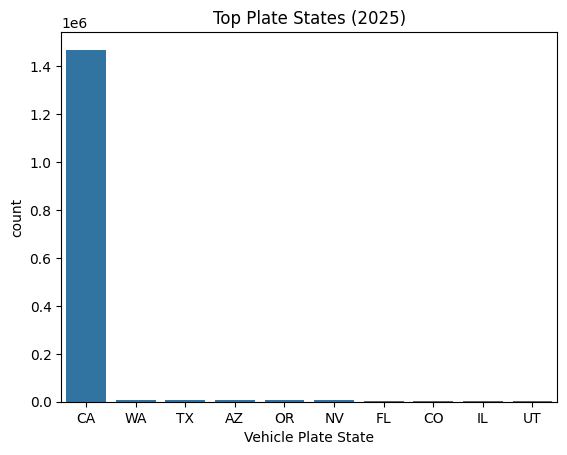

In [53]:
top_states = df_25['Vehicle Plate State'].value_counts().head(10).index

sns.countplot(
    data=df_25,
    x='Vehicle Plate State',
    order=top_states
)

plt.title('Top Plate States (2025)')
plt.show()

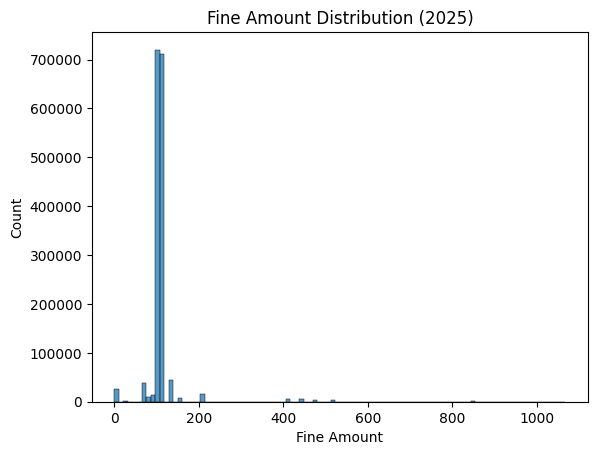

In [56]:
sns.histplot(df_25['Fine Amount'], bins=100)
plt.title('Fine Amount Distribution (2025)')
plt.show()

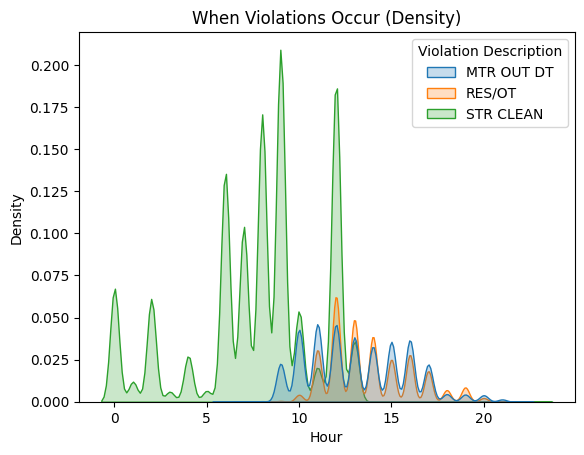

In [57]:
top_v = df_25['Violation Description'].value_counts().head(3).index

sns.kdeplot(
    data=df_25[df_25['Violation Description'].isin(top_v)],
    x='Hour',
    hue='Violation Description',
    fill=True
)

plt.title('When Violations Occur (Density)')
plt.show()

In [60]:
top_plates = (
    df_25['Vehicle Plate']
    .value_counts()
    .head(10)
)
top_plates

Vehicle Plate
9EQP478    328
70426W1    287
8ZCX018    269
7TQN093    266
82772A2    260
BRR4427    249
7HYR777    249
9JFX959    247
EP19455    242
11932J2    235
Name: count, dtype: int64

In [61]:
top_plate_fines = (
    df_25.groupby('Vehicle Plate')['Fine Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_plate_fines)

Vehicle Plate
9EQP478    34095
8ALU169    32113
70426W1    31330
7TQN093    28447
7HYR777    28370
9JFX959    28259
82772A2    28080
8ZCX018    27441
11932J2    27381
EP19455    26186
Name: Fine Amount, dtype: int64


In [64]:
avg_fine = round(df_25['Fine Amount'].mean(),2)
print("Average fine:", avg_fine)

Average fine: 108.39


In [65]:
median_fine = df_25['Fine Amount'].median()
print("Median fine:", median_fine)

Median fine: 105.0


In [66]:
expensive_violations = (
    df_25.groupby('Violation Description')['Fine Amount']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(expensive_violations)

Violation Description
ILG PRK BL    866.000000
ON STREET     858.450000
OFF STREET    857.800000
ON ST LST     855.380068
OFF ST LST    855.215116
BL ZNE BLK    509.687500
B ZN NO DP    502.347913
WHLCHR ACC    500.346876
B ZN XHTCH    496.042918
BUS ZONE      428.553718
Name: Fine Amount, dtype: float64


In [67]:
common_violations = df_25['Violation Description'].value_counts().head(10)
print(common_violations)

Violation Description
STR CLEAN     623884
MTR OUT DT    189086
RES/OT        136915
METER DTN      66279
FAIL DISPL     59342
NO PLATES      55697
YEL ZONE       48464
PRK GRADE      38800
RED ZONE       32912
DRIVEWAY       32127
Name: count, dtype: int64


In [70]:
repeat_offenders = (
    df_25['Vehicle Plate']
    .value_counts()
)

# plates with more than 10 tickets
repeat_offenders = repeat_offenders[repeat_offenders > 10]

print(repeat_offenders.size)

19966


In [73]:
tickets_per_plate = df_25.groupby('Vehicle Plate').size()
tickets_per_plate

Vehicle Plate
$U18721    1
0000000    1
00001B4    1
00001B9    2
00009H2    2
          ..
ZZW54N     2
ZZX227     3
ZZZLDA     2
ZZZZZTT    1
dp506ul    1
Length: 542503, dtype: int64

In [74]:
tickets_per_plate.mean()

2.8447437157029545

In [75]:
tickets_per_plate.median()

1.0

In [76]:
street_stats = (
    df_25.groupby('streets')
    .agg(
        ticket_count=('Citation Number','count'),
        avg_fine=('Fine Amount','mean'),
        total_fine=('Fine Amount','sum')
    )
    .sort_values('ticket_count', ascending=False)
)

print(street_stats.head(10))

               ticket_count    avg_fine  total_fine
streets                                            
MISSION ST            46005  116.727377     5370043
CALIFORNIA ST         18193  105.074644     1911623
POST ST               15210  110.692571     1683634
SUTTER ST             14559  117.618930     1712414
FOLSOM ST             13716  110.082896     1509897
SACRAMENTO ST         13700  105.240292     1441792
HARRISON ST           13431  105.795845     1420944
FILLMORE ST           13239  108.787069     1440232
BUSH ST               13204  105.076265     1387427
PINE ST               12232  104.132685     1273751
